# Corr-SAOU spatial extension demo: 16×16 → 32×32 / 64×64

This notebook trains a periodic, fully convolutional shell-force CNEEP model **once at 16×16**, then evaluates the exact same parameters at larger lattices. Add any valid integer lattice size to `TEST_SIZES` to test another extension.

Because the model returns a spatial mean calibrated on the training area, extensive EP is reconstructed as

`predicted total EP(L) = model native output(L) × L² / 16²`.

The local prediction uses the equivalent normalization `raw map / 16²`. No retraining, interpolation, or parameter resizing is performed.

In [12]:
from pathlib import Path
import sys
from dataclasses import replace

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from tqdm.auto import tqdm

# Set this to the directory containing models/, utils/, and shell_force.py.
# Example (Windows): KNEEP_ROOT = Path(r'C:/Users/your-name/path/to/KNEEP')
KNEEP_ROOT = Path(r'/home/ldh041203/projects/KNEEP')  # <-- required
KNEEP_ROOT = KNEEP_ROOT.expanduser().resolve()
if not (KNEEP_ROOT / 'models' / 'saou.py').is_file() or not (KNEEP_ROOT / 'shell_force.py').is_file():
    raise FileNotFoundError(f'KNEEP_ROOT is not a KNEEP repository: {KNEEP_ROOT}')
if str(KNEEP_ROOT) not in sys.path:
    sys.path.insert(0, str(KNEEP_ROOT))

from models import saou
from models.saou import SAOUConfig
from utils.training import (
    TrainingConfig, train_model, predict_epr_increments, predict_epr_branch_maps,
)

print('KNEEP root:', KNEEP_ROOT)
print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())

KNEEP root: /home/ldh041203/projects/KNEEP
PyTorch: 2.6.0+cu124 | CUDA: True


In [14]:
# Demo controls
TRAIN_L = 16
TEST_SIZES = (16, 32, 64)  # Add another size here, e.g. 48 or 96.
TRAIN_ENSEMBLES = 64
TRAIN_FRAMES = 1000
TEST_ENSEMBLES = 1
TEST_FRAMES = 10000
BURN_STEPS = 10000
N_ITER = 3000
SEED = 3

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MAX_DISTANCE = 4
HIDDEN_CHANNELS = 64
HIDDEN_LAYERS = 3
VAL_RATIO = 0.2
TRAINING = TrainingConfig(alpha=-0.5, iterations=N_ITER, train_batch_size=256,
    validation_batch_size=256, prediction_batch_size=256, learning_rate=1e-3,
    weight_decay=1e-4, gradient_clip=1.0, validate_every=max(N_ITER // 20, 1),
    train_fraction=1.0 - VAL_RATIO)

A = 0.5
amplitudes = tuple(A / np.sqrt(k) for k in range(1, MAX_DISTANCE + 1))
omega0 = sum(amplitudes) + 0.2
SAOU_TRAIN = SAOUConfig(lattice_size=TRAIN_L, radii=tuple(range(1, MAX_DISTANCE + 1)),
    amplitudes=amplitudes, gamma=1.0, omega0=omega0, temperature=1.0, dt=1e-2)
dt_eff = SAOU_TRAIN.effective_dt
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Device:', DEVICE, '| train size:', TRAIN_L, '| test sizes:', TEST_SIZES)

Device: cuda:0 | train size: 16 | test sizes: (16, 32, 64)


## 1. Generate only the 16×16 training data

In [15]:
train_video_all = saou.simulate_trajectories(
    SAOU_TRAIN, n_trajectories=TRAIN_ENSEMBLES, n_samples=TRAIN_FRAMES,
    burn_steps=BURN_STEPS, seed=SEED, simulation_device=DEVICE,
    storage_dtype=torch.float32, progress=True,
)
n_train = int(TRAIN_ENSEMBLES * (1.0 - VAL_RATIO))
train_video = train_video_all[:n_train]
val_video = train_video_all[n_train:]

print('train:', tuple(train_video.shape), '| validation:', tuple(val_video.shape))
print('All trajectory storage remains on CPU:', train_video.device)

train: (51, 1000, 2, 16, 16) | validation: (13, 1000, 2, 16, 16)
All trajectory storage remains on CPU: cpu


## 2. Train once at 16×16

In [16]:
training_result = train_model(train_video, val_video, TRAINING, model_seed=SEED, device=DEVICE,
    n_components=2, hidden_channels=HIDDEN_CHANNELS, hidden_layers=HIDDEN_LAYERS,
    max_distance=MAX_DISTANCE, activation='elu', progress=True)
model = training_result.model
history_iter = training_result.history_iterations
history_train = training_result.train_losses
history_val = training_result.validation_losses
trained_parameters_16 = {name: value.detach().cpu().clone() for name, value in model.state_dict().items()}
print(f'Loaded best 16x16 model at iteration {training_result.best_iteration}; validation loss={training_result.best_validation_loss:.6e}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Loaded best 16x16 model at iteration 300; validation loss=-3.790525e-01
Parameters: 63,690


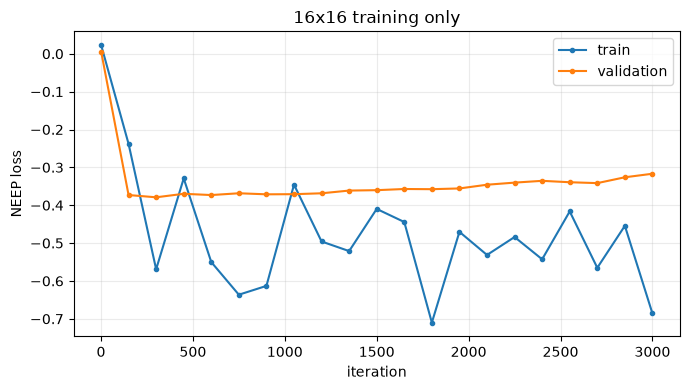

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(history_iter, history_train, 'o-', ms=3, label='train')
plt.plot(history_iter, history_val, 'o-', ms=3, label='validation')
plt.xlabel('iteration')
plt.ylabel('NEEP loss')
plt.title('16x16 training only')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Reuse the unchanged model at arbitrary lattice sizes

`evaluate_extension(L)` generates new SAOU data at size `L`, uses the fixed 16×16 normalization statistics, and applies the area correction only after model inference.

In [18]:
def evaluate_extension(L, n_frames=TEST_FRAMES, n_ensembles=TEST_ENSEMBLES):
    L = int(L)
    if L <= 2 * MAX_DISTANCE:
        raise ValueError(f'L={L} is too small for max_distance={MAX_DISTANCE}.')
    config = replace(SAOU_TRAIN, lattice_size=L)
    video = saou.simulate_trajectories(config, n_ensembles, n_frames, BURN_STEPS,
        SEED + 10_000 + L, DEVICE, torch.float32, progress=True)

    train_sites = TRAIN_L ** 2
    test_sites = L ** 2
    area_factor = test_sites / train_sites
    native_total = predict_epr_increments(training_result, video, TRAINING.prediction_batch_size, DEVICE)
    pred_total = area_factor * native_total
    gt_total = saou.exact_epr_increments(video, config, TRAINING.prediction_batch_size, DEVICE)
    first_maps = predict_epr_branch_maps(training_result, video[:1, :2], 1, DEVICE)[0]
    pred_first_map = first_maps.sum(axis=0) / train_sites
    first = video[0, 0].to(DEVICE, dtype=torch.float64).permute(1, 2, 0)
    second = video[0, 1].to(DEVICE, dtype=torch.float64).permute(1, 2, 0)
    operators = saou._build_operators(config)
    gt_first_map = ((saou.irreversible_velocity(0.5 * (first + second), operators, config.omega0)
        * (second - first)).sum(dim=-1) / config.temperature).cpu().numpy()
    result = dict(
        L=L, sites=test_sites, area_factor=area_factor,
        native_total=native_total, pred_total=pred_total, gt_total=gt_total,
        pred_density=pred_total / test_sites, gt_density=gt_total / test_sites,
        pred_first_map=pred_first_map, gt_first_map=gt_first_map,
        r2=r2_score(gt_total, pred_total),
    )

    # Evaluation must not mutate or resize any learned parameter/buffer.
    current_state = model.state_dict()
    assert current_state.keys() == trained_parameters_16.keys()
    for name, reference in trained_parameters_16.items():
        current = current_state[name].detach().cpu()
        assert current.shape == reference.shape and torch.equal(current, reference), name
    return result

print('Extension evaluator ready. The trained state is frozen and checked after every size.')

Extension evaluator ready. The trained state is frozen and checked after every size.


In [19]:
extension_results = {}
for lattice_size in TEST_SIZES:
    extension_results[lattice_size] = evaluate_extension(lattice_size)
print('Finished:', tuple(extension_results))

Finished: (16, 32, 64)


## 4. Scaling summary

For a spatially homogeneous system, mean total EP should grow approximately with area, while EP per site should remain approximately invariant.

    L  area factor       GT total     pred total   GT scale  pred scale       R^2
---------------------------------------------------------------------------------
   16        1.000   4.165596e-01   4.014606e-01      1.000       1.000     0.931
   32        4.000   1.750077e+00   1.671050e+00      4.201       4.162     0.929
   64       16.000   7.030922e+00   6.722850e+00     16.879      16.746     0.925


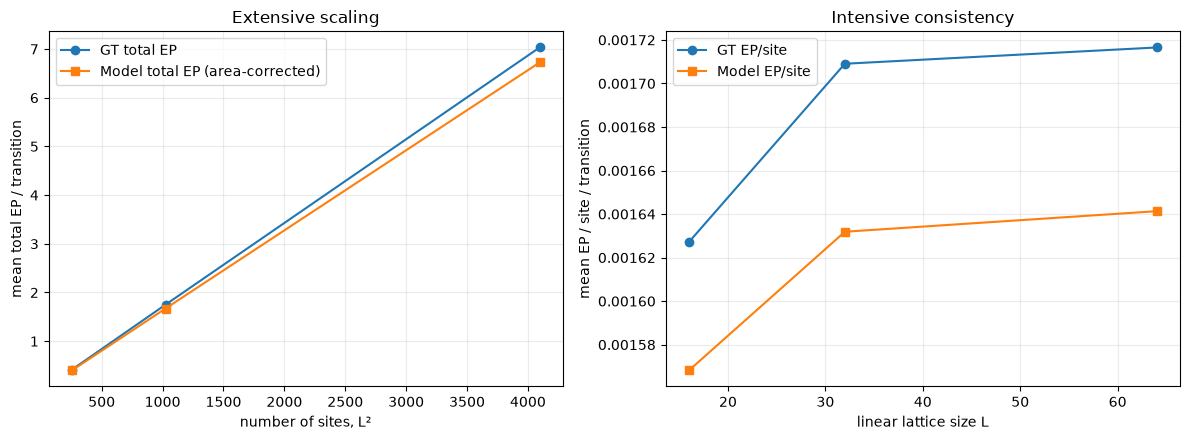

In [20]:
reference = extension_results[TRAIN_L]
header = f"{'L':>5} {'area factor':>12} {'GT total':>14} {'pred total':>14} {'GT scale':>10} {'pred scale':>11} {'R^2':>9}"
print(header)
print('-' * len(header))
for L, result in extension_results.items():
    gt_scale = result['gt_total'].mean() / reference['gt_total'].mean()
    pred_scale = result['pred_total'].mean() / reference['pred_total'].mean()
    print(
        f"{L:5d} {result['area_factor']:12.3f} {result['gt_total'].mean():14.6e} "
        f"{result['pred_total'].mean():14.6e} {gt_scale:10.3f} {pred_scale:11.3f} {result['r2']:9.3f}"
    )

sizes = np.asarray(list(extension_results), dtype=float)
areas = sizes ** 2
gt_means = np.asarray([extension_results[int(L)]['gt_total'].mean() for L in sizes])
pred_means = np.asarray([extension_results[int(L)]['pred_total'].mean() for L in sizes])
gt_density_means = np.asarray([extension_results[int(L)]['gt_density'].mean() for L in sizes])
pred_density_means = np.asarray([extension_results[int(L)]['pred_density'].mean() for L in sizes])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(areas, gt_means, 'o-', label='GT total EP')
axes[0].plot(areas, pred_means, 's-', label='Model total EP (area-corrected)')
axes[0].set_xlabel('number of sites, L²')
axes[0].set_ylabel('mean total EP / transition')
axes[0].set_title('Extensive scaling')
axes[0].grid(alpha=0.25)
axes[0].legend()
axes[1].plot(sizes, gt_density_means, 'o-', label='GT EP/site')
axes[1].plot(sizes, pred_density_means, 's-', label='Model EP/site')
axes[1].set_xlabel('linear lattice size L')
axes[1].set_ylabel('mean EP / site / transition')
axes[1].set_title('Intensive consistency')
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Cumulative EP and per-transition agreement

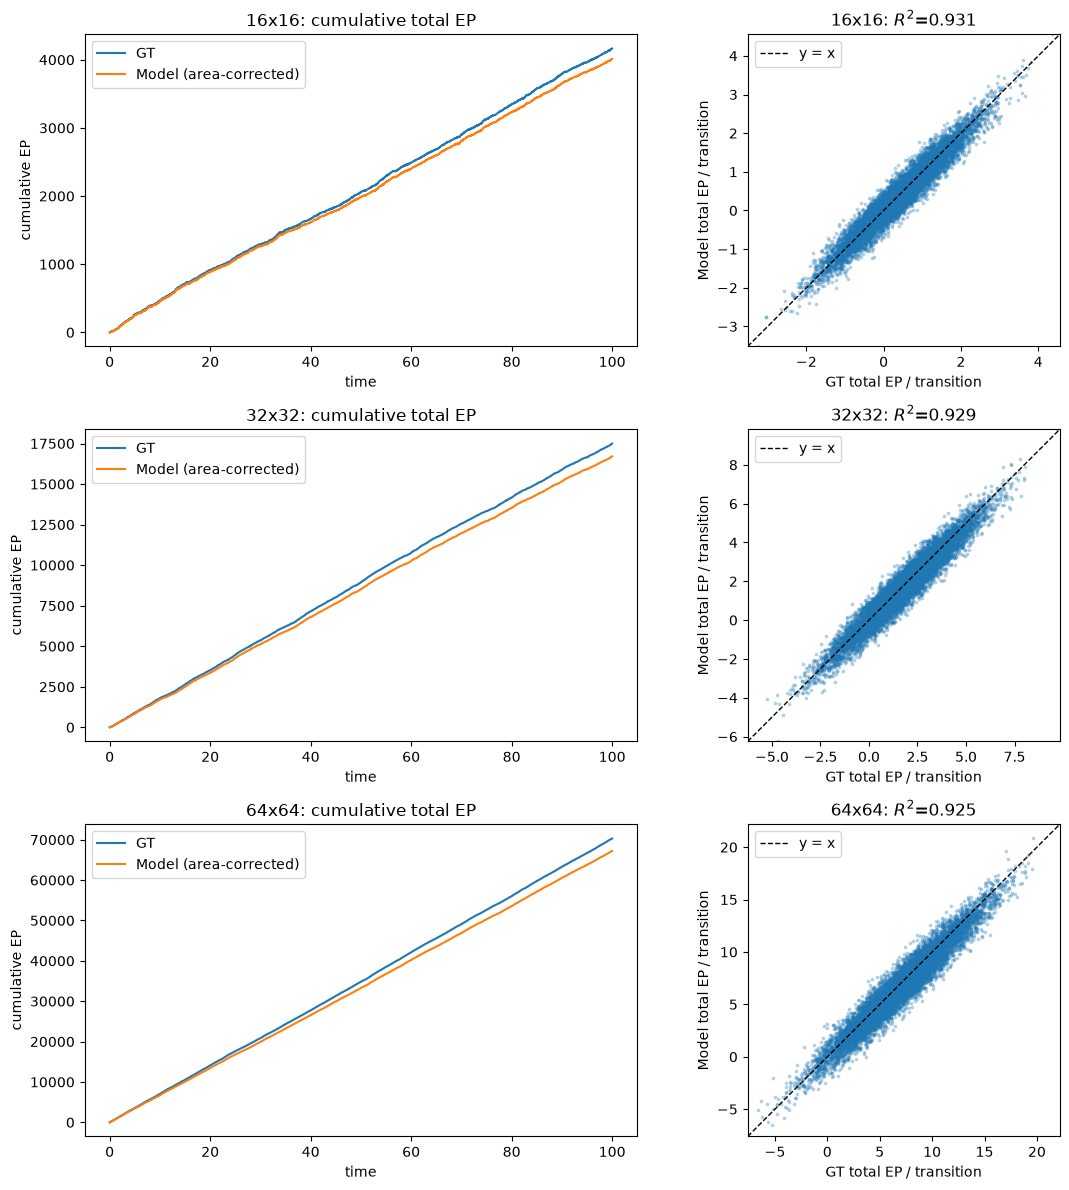

In [21]:
fig, axes = plt.subplots(len(TEST_SIZES), 2, figsize=(12, 4 * len(TEST_SIZES)), squeeze=False)
for row, L in enumerate(TEST_SIZES):
    result = extension_results[L]
    time = (np.arange(len(result['gt_total'])) + 1) * dt_eff
    axes[row, 0].plot(time, np.cumsum(result['gt_total']), label='GT')
    axes[row, 0].plot(time, np.cumsum(result['pred_total']), label='Model (area-corrected)')
    axes[row, 0].set_title(f'{L}x{L}: cumulative total EP')
    axes[row, 0].set_xlabel('time')
    axes[row, 0].set_ylabel('cumulative EP')
    axes[row, 0].legend()

    lo = min(result['gt_total'].min(), result['pred_total'].min())
    hi = max(result['gt_total'].max(), result['pred_total'].max())
    axes[row, 1].scatter(result['gt_total'], result['pred_total'], s=3, alpha=0.25)
    axes[row, 1].plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')
    axes[row, 1].set_xlim(lo, hi)
    axes[row, 1].set_ylim(lo, hi)
    axes[row, 1].set_aspect('equal', adjustable='box')
    axes[row, 1].set_xlabel('GT total EP / transition')
    axes[row, 1].set_ylabel('Model total EP / transition')
    axes[row, 1].set_title(f'{L}x{L}: $R^2$={result["r2"]:.3f}')
    axes[row, 1].legend()
plt.tight_layout()
plt.show()

## 6. First-transition local EP maps

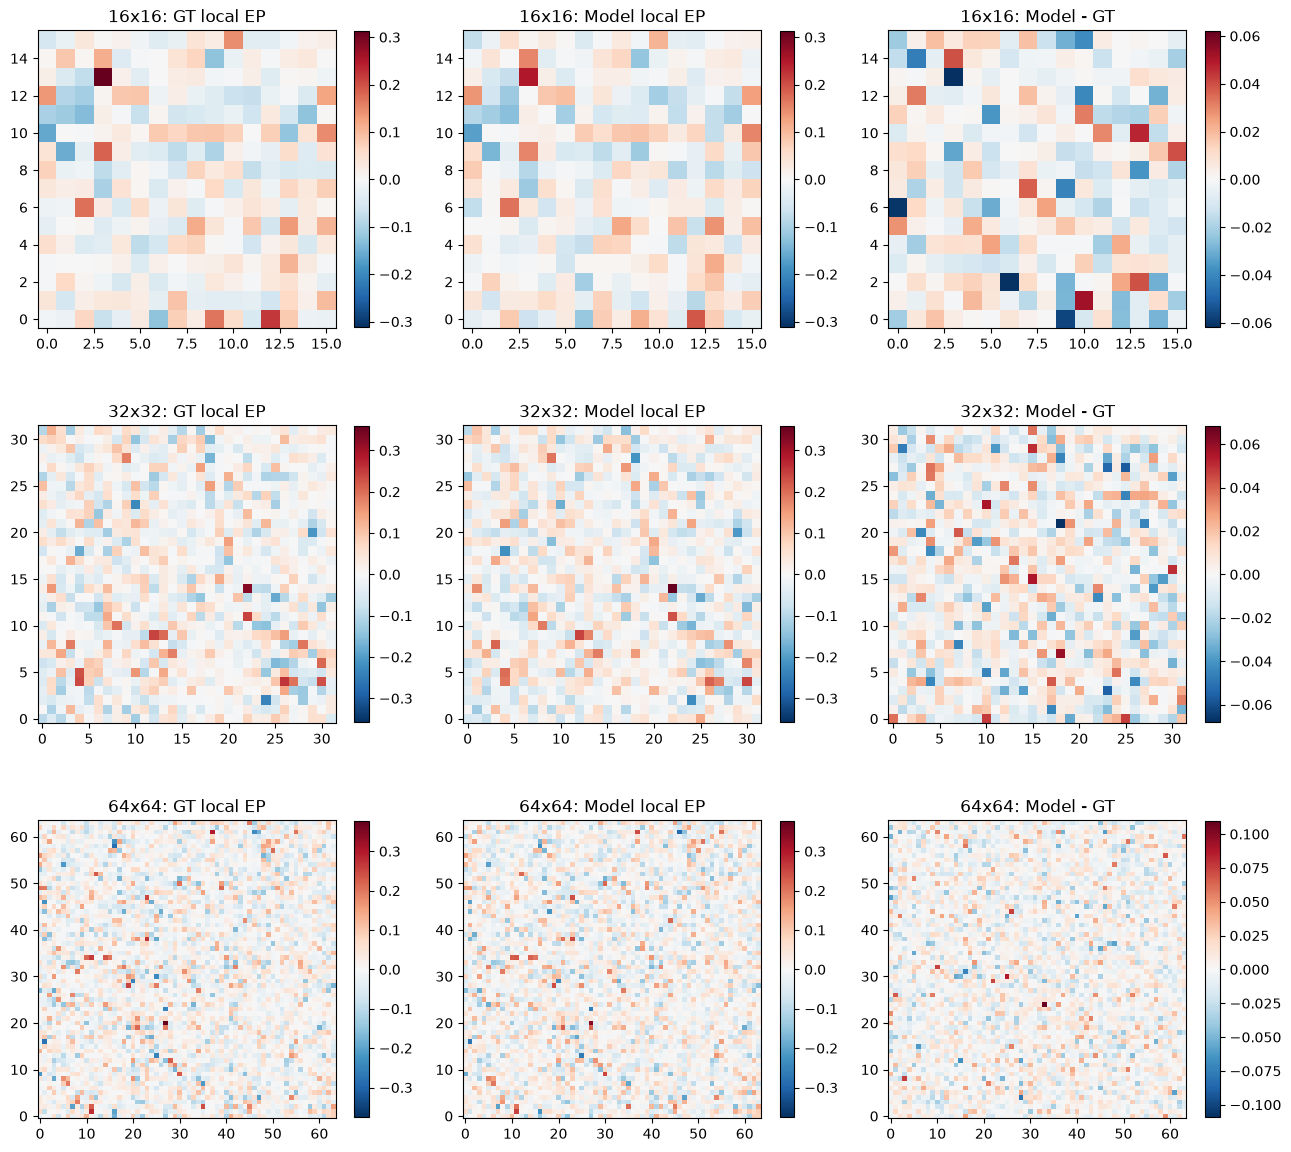

All extension evaluations used exactly the saved 16x16 parameter tensors.


In [22]:
fig, axes = plt.subplots(len(TEST_SIZES), 3, figsize=(13, 4 * len(TEST_SIZES)), squeeze=False)
for row, L in enumerate(TEST_SIZES):
    result = extension_results[L]
    gt_map = result['gt_first_map']
    pred_map = result['pred_first_map']
    diff_map = pred_map - gt_map
    vmax = max(np.abs(gt_map).max(), np.abs(pred_map).max(), 1e-12)
    diff_vmax = max(np.abs(diff_map).max(), 1e-12)
    panels = [
        (gt_map, -vmax, vmax, 'GT local EP'),
        (pred_map, -vmax, vmax, 'Model local EP'),
        (diff_map, -diff_vmax, diff_vmax, 'Model - GT'),
    ]
    for col, (array, vmin, vmax_panel, title) in enumerate(panels):
        image = axes[row, col].imshow(
            array.T, origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax_panel,
        )
        axes[row, col].set_title(f'{L}x{L}: {title}')
        fig.colorbar(image, ax=axes[row, col], shrink=0.8)
plt.tight_layout()
plt.show()
print('All extension evaluations used exactly the saved 16x16 parameter tensors.')